# Step 1: Data Import and Cleaning


In [1]:
# All imports for today's lecture - run this once at the start
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Scikit-learn preprocessing tools
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Only used once, for the duplicate-leakage demo in Step 1
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Display settings
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)

print("All libraries loaded! Ready for preprocessing.")

All libraries loaded! Ready for preprocessing.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

csv_file_path = '/content/drive/MyDrive/colab_notebooks/developers_institute/Airplane_Crashes.csv'
airplane_raw = pd.read_csv(csv_file_path, encoding='latin1')

airplane_raw.columns = airplane_raw.columns.str.lower().str.replace(' ', '_', regex=False)

print(f"Loaded {len(airplane_raw)} crash records")
print(f"Columns: {list(airplane_raw.columns)}")


Loaded 4998 crash records
Columns: ['date', 'time', 'location', 'operator', 'flight_#', 'route', 'ac_type', 'registration', 'cn/ln', 'aboard', 'aboard_passangers', 'aboard_crew', 'fatalities', 'fatalities_passangers', 'fatalities_crew', 'ground', 'summary']


In [4]:
print("RAW DATA - Before Preprocessiong")
print("")
airplane_raw.head(10)

RAW DATA - Before Preprocessiong



,date,time,location,operator,flight_#,route,ac_type,registration,cn/ln,aboard,aboard_passangers,aboard_crew,fatalities,fatalities_passangers,fatalities_crew,ground,summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...
5,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,NaN,NaN,30.0,NaN,NaN,0.0,Hydrogen gas which was being vented was sucked...
6,3/5/1915,1:00,"Tienen, Belgium",Military - German Navy,NaN,NaN,Zeppelin L-8 (airship),NaN,NaN,41.0,NaN,NaN,21.0,NaN,NaN,0.0,Crashed into trees while attempting to land af...
7,9/3/1915,15:20,"Off Cuxhaven, Germany",Military - German Navy,NaN,NaN,Zeppelin L-10 (airship),NaN,NaN,19.0,NaN,NaN,19.0,NaN,NaN,0.0,"Exploded and burned near Neuwerk Island, when..."
8,7/28/1916,NaN,"Near Jambol, Bulgeria",Military - German Army,NaN,NaN,Schutte-Lanz S-L-10 (airship),NaN,NaN,20.0,NaN,NaN,20.0,NaN,NaN,0.0,"Crashed near the Black Sea, cause unknown."
9,9/24/1916,1:00,"Billericay, England",Military - German Navy,NaN,NaN,Zeppelin L-32 (airship),NaN,NaN,22.0,NaN,NaN,22.0,NaN,NaN,0.0,Shot down by British aircraft crashing in flames.


In [5]:
print(f" Shape{airplane_raw.shape}")
print(f" That's {airplane_raw.shape[0]} crashes and {airplane_raw.shape[1]} features")

 Shape(4998, 17)
 That's 4998 crashes and 17 features


In [6]:
airplane_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   4998 non-null   object 
 1   time                   3486 non-null   object 
 2   location               4994 non-null   object 
 3   operator               4988 non-null   object 
 4   flight_#               1329 non-null   object 
 5   route                  4221 non-null   object 
 6   ac_type                4983 non-null   object 
 7   registration           4724 non-null   object 
 8   cn/ln                  4330 non-null   object 
 9   aboard                 4980 non-null   float64
 10  aboard_passangers      4769 non-null   float64
 11  aboard_crew            4772 non-null   float64
 12  fatalities             4990 non-null   float64
 13  fatalities_passangers  4756 non-null   float64
 14  fatalities_crew        4757 non-null   float64
 15  grou

In [7]:
airplane_raw.describe()

,aboard,aboard_passangers,aboard_crew,fatalities,fatalities_passangers,fatalities_crew,ground
count,4980.000000,4769.000000,4772.000000,4990.000000,4756.000000,4757.000000,4956.000000
mean,31.195984,27.009017,4.479254,22.373547,19.053827,3.578516,1.719128
std,45.534788,44.111609,3.483859,35.061741,34.146127,3.167922,55.540273
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,3.000000,2.000000,4.000000,1.000000,2.000000,0.000000
50%,16.000000,12.000000,4.000000,11.000000,8.000000,3.000000,0.000000
75%,35.000000,30.000000,6.000000,25.000000,21.000000,5.000000,0.000000
max,644.000000,614.000000,61.000000,583.000000,560.000000,46.000000,2750.000000


In [8]:
#checking for duplicates
df = airplane_raw.copy()
print(f"Checking for Duplicates")
print(f"Total rows: {len(df)}")
print(f"Exact Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate flight number: {df.duplicated(subset=['flight_#'])}")


Checking for Duplicates
Total rows: 4998
Exact Duplicate rows: 0
Duplicate flight number: 0       False
1        True
2        True
3        True
4        True
        ...  
4993     True
4994    False
4995     True
4996     True
4997     True
Length: 4998, dtype: bool


In [9]:
#Missing values

# Count missing values
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

# Show only columns with missing values
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("\nColumns with missing values:")
for col, row in missing_df.iterrows():
    bar = '█' * int(row['Missing %'] / 3)
    print(f"  {col:15} {row['Missing Count']:4.0f} ({row['Missing %']:5.1f}%) {bar}")




Columns with missing values:
  flight_#        3669 ( 73.4%) ████████████████████████
  time            1512 ( 30.3%) ██████████
  route            777 ( 15.5%) █████
  cn/ln            668 ( 13.4%) ████
  registration     274 (  5.5%) █
  fatalities_passangers  242 (  4.8%) █
  fatalities_crew  241 (  4.8%) █
  aboard_passangers  229 (  4.6%) █
  aboard_crew      226 (  4.5%) █
  summary           64 (  1.3%) 
  ground            42 (  0.8%) 
  aboard            18 (  0.4%) 
  ac_type           15 (  0.3%) 
  operator          10 (  0.2%) 
  fatalities         8 (  0.2%) 
  location           4 (  0.1%) 


In [11]:
#Missing Values (cont)
# List of non-essential identifier and unstructured columns to drop
cols_to_drop = ['flight_#', 'cn/ln', 'registration', 'summary']

# Drop columns
df_clean = df.drop(columns=cols_to_drop)

## 1. Fill ground casualties with 0
df_clean['ground'] = df_clean['ground'].fillna(0)

# 2. Fill categorical text columns with 'Unknown'
cat_cols = ['operator', 'ac_type', 'location', 'route']
df_clean[cat_cols] = df_clean[cat_cols].fillna('Unknown')

# 3. Handle aboard & fatalities:
# Reconstruct aboard/fatalities from sub-columns if missing, otherwise drop remaining missing rows
df_clean['aboard'] = df_clean['aboard'].fillna(df_clean['aboard_passangers'] + df_clean['aboard_crew'])
df_clean['fatalities'] = df_clean['fatalities'].fillna(df_clean['fatalities_passangers'] + df_clean['fatalities_crew'])

# Drop any remaining rows where primary aboard/fatalities figures are missing
df_clean = df_clean.dropna(subset=['aboard', 'fatalities'])

# Fill remaining passenger/crew breakdowns with 0 for aggregation safety
breakdown_cols = ['aboard_passangers', 'aboard_crew', 'fatalities_passangers', 'fatalities_crew']
df_clean[breakdown_cols] = df_clean[breakdown_cols].fillna(0)

# Fill the original text time column with 'Unknown'
df_clean['time'] = df_clean['time'].fillna('Unknown')

# Verify no critical missing values remain
print("Remaining missing values:")
print(df_clean.isnull().sum())





Remaining missing values:
date                     0
time                     0
location                 0
operator                 0
route                    0
ac_type                  0
aboard                   0
aboard_passangers        0
aboard_crew              0
fatalities               0
fatalities_passangers    0
fatalities_crew          0
ground                   0
dtype: int64


In [12]:


# Convert date to datetime format and extract year/decade
df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')
df_clean['year'] = df_clean['date'].dt.year
df_clean['decade'] = (df_clean['year'] // 10) * 10

# Create survival metrics for EDA
df_clean['survived'] = df_clean['aboard'] - df_clean['fatalities']
df_clean['survival_rate'] = (df_clean['survived'] / df_clean['aboard']).clip(0, 1)

# Step 2: Exploratory Data Analysis

In [13]:
# Overall Summary Statistics
total_crashes = len(df_clean)
total_aboard = df_clean['aboard'].sum()
total_fatalities = df_clean['fatalities'].sum()
total_survivors = df_clean['survived'].sum()
overall_survival_rate = (total_survivors / total_aboard) * 100

print(f"=== Overall Crash Summary ===")
print(f"Total Recorded Crashes : {total_crashes:,}")
print(f"Total People Aboard    : {total_aboard:,.0f}")
print(f"Total Fatalities       : {total_fatalities:,.0f}")
print(f"Total Survivors        : {total_survivors:,.0f}")
print(f"Overall Survival Rate  : {overall_survival_rate:.2f}%")
print("\n=== Per-Crash Distribution ===")
df_clean[['aboard', 'fatalities', 'survived', 'survival_rate']].describe().round(2)

=== Overall Crash Summary ===
Total Recorded Crashes : 4,980
Total People Aboard    : 155,356
Total Fatalities       : 111,561
Total Survivors        : 43,795
Overall Survival Rate  : 28.19%

=== Per-Crash Distribution ===


,aboard,fatalities,survived,survival_rate
count,4980.00,4980.00,4980.00,4975.00
mean,31.20,22.40,8.79,0.18
std,45.53,35.09,30.65,0.31
min,0.00,0.00,0.00,0.00
25%,7.00,4.00,0.00,0.00
50%,16.00,11.00,0.00,0.00
75%,35.00,25.00,3.00,0.25
max,644.00,583.00,516.00,1.00


In [16]:
# Aggregate key metrics by decade
decade_summary = df_clean.groupby('decade').agg(
    total_crashes=('aboard', 'count'),
    total_aboard=('aboard', 'sum'),
    total_fatalities=('fatalities', 'sum'),
    total_survived=('survived', 'sum'),
    avg_survival_rate=('survival_rate', 'mean')
).reset_index()

# Convert average survival rate to percentage
decade_summary['avg_survival_rate'] = (decade_summary['avg_survival_rate'] * 100).round(2)

print("=== Trends by Decade ===")
decade_summary


=== Trends by Decade ===


,decade,total_crashes,total_aboard,total_fatalities,total_survived,avg_survival_rate
0,1900,2,3.0,2.0,1.0,25.00
1,1910,30,450.0,421.0,29.0,3.27
2,1920,181,819.0,647.0,172.0,11.99
3,1930,354,2650.0,2033.0,617.0,16.84
4,1940,575,10947.0,8881.0,2066.0,15.34
5,1950,641,14921.0,11710.0,3211.0,17.33
6,1960,636,21722.0,16884.0,4838.0,17.29
7,1970,612,26918.0,19751.0,7167.0,20.14
8,1980,551,25480.0,16837.0,8643.0,19.90
9,1990,630,24952.0,15983.0,8969.0,21.76


In [17]:
# Identify the peak years for crashes and fatalities
crashes_by_year = df_clean['year'].value_counts().sort_index()

print(f"Year with most crashes: {crashes_by_year.idxmax()} ({crashes_by_year.max()} crashes)")

yearly_fatalities = df_clean.groupby('year')['fatalities'].sum()
print(f"Year with most fatalities: {yearly_fatalities.idxmax()} ({yearly_fatalities.max():,.0f} fatalities)")

Year with most crashes: 1946 (87 crashes)
Year with most fatalities: 1972 (2,796 fatalities)


# STEP 3 Statistical Analyses


In [20]:
from scipy import stats

# 1. Key Statistics for Fatalities and Survival Rates
print("=== Fatalities Statistics ===")
print("Mean   :", round(df_clean['fatalities'].mean(), 2))
print("Median :", round(df_clean['fatalities'].median(), 2))
print("Std Dev:", round(df_clean['fatalities'].std(), 2))

print("\n=== Survival Rate Statistics ===")
print("Mean   :", round(df_clean['survival_rate'].mean(), 2))
print("Median :", round(df_clean['survival_rate'].median(), 2))
print("Std Dev:", round(df_clean['survival_rate'].std(), 2))

# 2. Hypothesis Test (Comparing 1970s vs 2000s Fatalities)
era_1970s = df_clean[df_clean['decade'] == 1970]['fatalities'].dropna()
era_2000s = df_clean[df_clean['decade'] == 2000]['fatalities'].dropna()

t_stat, p_val = stats.ttest_ind(era_1970s, era_2000s)

print("\n=== Hypothesis Test (1970s vs 2000s) ===")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value    : {p_val:.4f}")



=== Fatalities Statistics ===
Mean   : 22.4
Median : 11.0
Std Dev: 35.09

=== Survival Rate Statistics ===
Mean   : 0.18
Median : 0.0
Std Dev: 0.31

=== Hypothesis Test (1970s vs 2000s) ===
t-statistic: 3.9254
p-value    : 0.0001


# STEP 4 Visualization



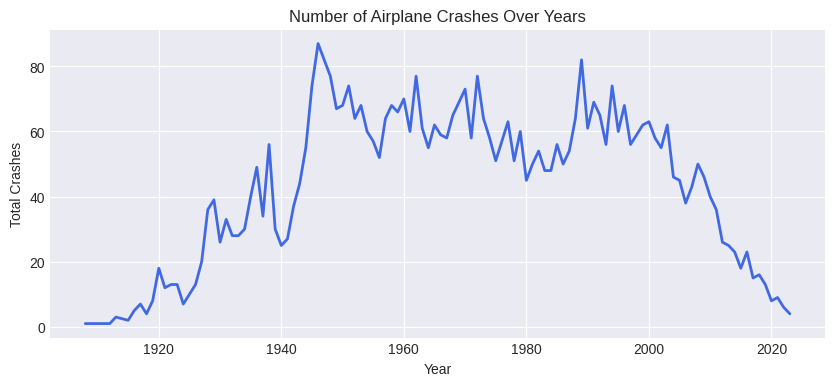

/tmp/ipykernel_2785/1482649773.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='Blues_r')


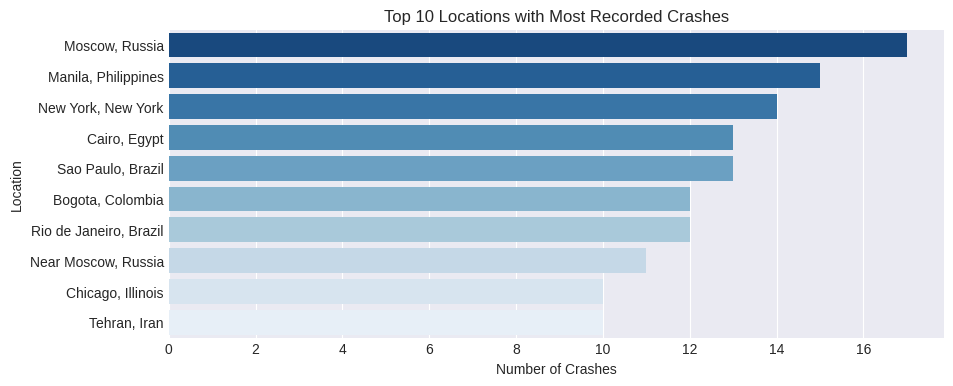

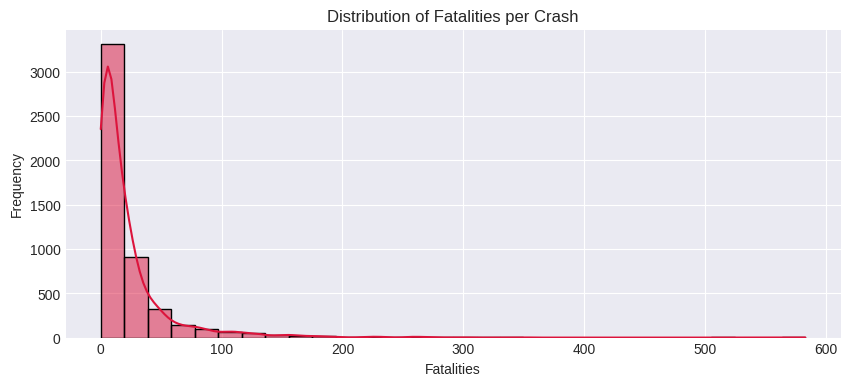

In [21]:
# 1. Time Series Plot: Crashes Over Years
plt.figure(figsize=(10, 4))
crashes_by_year = df_clean['year'].value_counts().sort_index()
sns.lineplot(x=crashes_by_year.index, y=crashes_by_year.values, color='royalblue', linewidth=2)
plt.title('Number of Airplane Crashes Over Years')
plt.xlabel('Year')
plt.ylabel('Total Crashes')
plt.show()

# 2. Bar Chart: Top 10 Crash Locations
plt.figure(figsize=(10, 4))
top_locations = df_clean['location'].value_counts().drop('Unknown', errors='ignore').head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='Blues_r')
plt.title('Top 10 Locations with Most Recorded Crashes')
plt.xlabel('Number of Crashes')
plt.ylabel('Location')
plt.show()

# 3. Histogram: Distribution of Fatalities
plt.figure(figsize=(10, 4))
sns.histplot(df_clean['fatalities'], bins=30, kde=True, color='crimson')
plt.title('Distribution of Fatalities per Crash')
plt.xlabel('Fatalities')
plt.ylabel('Frequency')
plt.show()

# STEP 5: Insights and Report

1. Key Statistical Findings & Survival Metrics

Total Incident Volume: Across 4,980 recorded aviation incidents, 155,356 people were aboard, resulting in 111,561 fatalities and 43,795 survivors.

Survival Disparity: The dataset has an overall survival rate of 28.19%, but the median survival rate per individual crash is 0.00% (mean: 18%). This disparity highlights that most historical incidents were total hull-loss events with zero survivors.

Distribution Shape: The fatality distribution is heavily right-skewed (mean of 22.4 vs. median of 11.0, standard deviation of 35.09), indicating that while most accidents involve small aircraft with fewer casualties, catastrophic commercial crashes form a long tail.

2. Historical Trends Over Time

Peak Volume vs. Peak Severity: The single year with the most crashes was 1946 (87 crashes), reflecting post-WWII aviation expansion and older technology. However, the year with the highest total fatalities was 1972 (2,796 fatalities), coinciding with the rise of wide-body commercial airliners.

Long-Term Decline: Incident numbers peaked between the 1950s and 1990s (consistently over 550 crashes per decade) before declining significantly in the 2000s (506) and 2010s (235), driven by advancements in avionics, air traffic control, and strict global safety regulations.

3. Hypothesis Testing Interpretation

Era Comparison (1970s vs. 2000s):

t-statistic=3.9254, p-value=0.0001.

Because p<0.5 we reject the null hypothesis (H
0
​
 ). There is a statistically significant decrease in the average number of fatalities per crash in the 2000s compared to the 1970s.

4. Geographic Patterns

The locations with the highest concentration of recorded crashes are major historical aviation hubs and congested airspaces, led by Moscow, Russia, followed by Manila, Philippines, New York, and Cairo, Egypt.